<a href="https://colab.research.google.com/github/Pubudu-98/Colab/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tensors in Deep Learning**

In [1]:
import torch
import numpy as np

In [2]:
data = [7, 8], [4, 6]

In [3]:
type(data)

tuple

In [4]:
x_data = torch.tensor(data)

In [5]:
type(x_data)

torch.Tensor

In [6]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [7]:
x_np

tensor([[7, 8],
        [4, 6]])

In [8]:
type(x_np)

torch.Tensor

In [9]:
x_np

tensor([[7, 8],
        [4, 6]])

In [10]:
tensor = torch.rand(2, 3)
tensor

tensor([[0.3296, 0.6896, 0.3699],
        [0.0874, 0.1911, 0.1349]])

In [11]:
print('Shape of Tensor: ', tensor.shape)
print('Datatype of Tensor: ', tensor.dtype)
print('Device tensor is stored on: ', tensor.device)

Shape of Tensor:  torch.Size([2, 3])
Datatype of Tensor:  torch.float32
Device tensor is stored on:  cpu


In [12]:
if torch.accelerator.is_available():
  tensor = tensor.to(torch.accelerator.current_accelerator())

In [13]:
tensor

tensor([[0.3296, 0.6896, 0.3699],
        [0.0874, 0.1911, 0.1349]], device='cuda:0')

**Datasets & DataLoaders**

In [14]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [15]:
training_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.00MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 142kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.55MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.7MB/s]


In [16]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [17]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

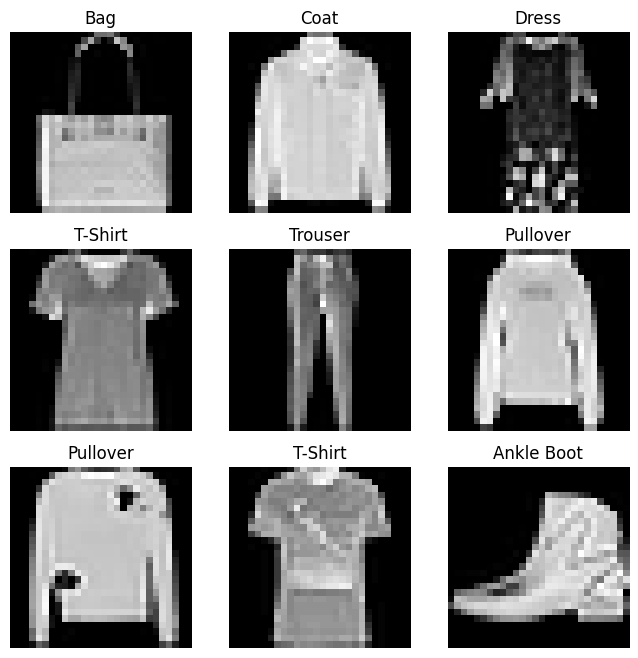

In [18]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [19]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label